# Multilingual LLM Quantization Research
## Evaluating the Impact of PTQ on Polish vs English Reasoning in Llama-3

**Author:** Muhammed Fariz Palli Valappil  
**Institution:** Vistula University, Warsaw  
**Year:** 2026  

### Research Question
Does 4-bit Post-Training Quantization degrade Polish reasoning
disproportionately compared to English in Meta-Llama-3-8B-Instruct?

### Key Finding
Polish degraded **46% more severely** than English under NF4 4-bit
quantization, completely erasing its 6-point full-precision advantage.
This is termed the **Convergence Effect**.

### NOTE FOR REPRODUCIBILITY:
#### This notebook requires a HuggingFace account with approved access to Meta-Llama-3-8B-Instruct.

Apply here: https://huggingface.co/meta-llama/Meta-Llama-3-8B-Instruct

Store your token in Colab Secrets as 'HF_TOKEN' before running.
Runtime: Google Colab with T4 GPU (15GB VRAM minimum)
Estimated runtime: ~45 minutes for all 6 evaluation conditions

## Step 1: Environment Setup

In [1]:
# Install required libraries
!pip install -q transformers accelerate bitsandbytes datasets

import torch
import gc
import requests
import json
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from google.colab import userdata
from huggingface_hub import login

# Authenticate with HuggingFace
HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN)

MODEL_ID = "meta-llama/Meta-Llama-3-8B-Instruct"
print("Environment ready!")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f}GB")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.4 MB/s eta 0:00:00
Environment ready!
GPU: Tesla T4
VRAM: 14.6GB


## Step 2: Load Belebele Benchmark (English + Polish)

In [2]:
def load_belebele(lang_code):
    url = f"https://huggingface.co/datasets/facebook/belebele/resolve/main/data/{lang_code}.jsonl"
    r = requests.get(url)
    return [json.loads(line) for line in r.text.strip().split("\n")]

belebele_en = load_belebele("eng_Latn")
belebele_pl = load_belebele("pol_Latn")

print(f"English problems loaded: {len(belebele_en)}")
print(f"Polish problems loaded:  {len(belebele_pl)}")
print(f"\nSample English question:")
print(f"  Q: {belebele_en[0]['question']}")
print(f"  Correct answer: {belebele_en[0]['correct_answer_num']}")

English problems loaded: 900
Polish problems loaded:  900

Sample English question:
  Q: According to the passage, what would not be considered an accurate tip for successfully playing the accordion?
  Correct answer: 1


## Step 3: Evaluation Function

In [3]:
def evaluate_belebele(model, tokenizer, dataset, language, n_samples=100):
    correct = 0
    total = 0

    for item in dataset[:n_samples]:
        prompt = f"""Read the passage and answer the question by responding with only the number 1, 2, 3, or 4.

Passage: {item['flores_passage']}

Question: {item['question']}

1. {item['mc_answer1']}
2. {item['mc_answer2']}
3. {item['mc_answer3']}
4. {item['mc_answer4']}

Answer (1, 2, 3, or 4):"""

        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        input_len = inputs["input_ids"].shape[-1]

        with torch.no_grad():
            output = model.generate(**inputs, max_new_tokens=5, do_sample=False)

        response = tokenizer.decode(output[0][input_len:], skip_special_tokens=True).strip()
        predicted = response[0] if response else "0"

        if predicted == item["correct_answer_num"]:
            correct += 1
        total += 1

        if total % 20 == 0:
            print(f"  [{total}/{n_samples}] Running accuracy: {correct/total:.2%}")

    accuracy = correct / total
    print(f"\n✅ Final accuracy ({language}): {accuracy:.2%} ({correct}/{total})")
    return accuracy

print("Evaluation function ready.")

Evaluation function ready.


## Step 4: Condition 1 — FP16 Baseline (Full Precision)
Loading the model at full 16-bit precision to establish the performance ceiling.

In [4]:
print("Loading FP16 model...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN)
model_fp16 = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, dtype=torch.float16, device_map="auto", token=HF_TOKEN
)
print(f"FP16 model loaded. Memory: {torch.cuda.memory_allocated()/1024**3:.1f}GB used")

Loading FP16 model...


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/51.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

FP16 model loaded. Memory: 11.9GB used


In [5]:
print("=== FP16 English ===")
fp16_en = evaluate_belebele(model_fp16, tokenizer, belebele_en, "EN", n_samples=100)

print("\n=== FP16 Polish ===")
fp16_pl = evaluate_belebele(model_fp16, tokenizer, belebele_pl, "PL", n_samples=100)

print(f"\n📊 FP16 SUMMARY:")
print(f"  English: {fp16_en:.2%}")
print(f"  Polish:  {fp16_pl:.2%}")
print(f"  Gap:     {fp16_en - fp16_pl:.2%}")

[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


=== FP16 English ===


[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/mai

  [20/100] Running accuracy: 85.00%


[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

...

  [60/100] Running accuracy: 80.00%


[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

  [80/100] Running accuracy: 78.75%


[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

  [100/100] Running accuracy: 78.00%

✅ Final accuracy (PL): 78.00% (78/100)

📊 FP16 SUMMARY:
  English: 72.00%
  Polish:  78.00%
  Gap:     -6.00%


## Step 5: Condition 2 — Q8 (8-bit Integer Quantization)
Using LLM.int8() via bitsandbytes. ~50% memory reduction.

In [6]:
del model_fp16
gc.collect()
torch.cuda.empty_cache()

q8_config = BitsAndBytesConfig(load_in_8bit=True)
print("Loading Q8 model...")
model_q8 = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=q8_config, device_map="auto", token=HF_TOKEN
)
print(f"Q8 model loaded. Memory: {torch.cuda.memory_allocated()/1024**3:.1f}GB used")

Loading Q8 model...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Q8 model loaded. Memory: 8.5GB used


In [7]:
print("=== Q8 English ===")
q8_en = evaluate_belebele(model_q8, tokenizer, belebele_en, "EN", n_samples=100)

print("\n=== Q8 Polish ===")
q8_pl = evaluate_belebele(model_q8, tokenizer, belebele_pl, "PL", n_samples=100)

print(f"\n📊 Q8 SUMMARY:")
print(f"  English: {q8_en:.2%}")
print(f"  Polish:  {q8_pl:.2%}")
print(f"  Gap:     {q8_en - q8_pl:.2%}")

[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Q8 English ===


/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Se

  [20/100] Running accuracy: 65.00%


[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

...

  [60/100] Running accuracy: 70.00%


[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

  [80/100] Running accuracy: 70.00%


[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

  [100/100] Running accuracy: 70.00%

✅ Final accuracy (PL): 70.00% (70/100)

📊 Q8 SUMMARY:
  English: 60.00%
  Polish:  70.00%
  Gap:     -10.00%


## Step 6: Condition 3 — Q4 NF4 (4-bit NormalFloat Quantization)
Using NF4 via bitsandbytes. ~75% memory reduction. This is the
default for most consumer-grade local AI deployments.

In [8]:
del model_q8
gc.collect()
torch.cuda.empty_cache()

q4_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"
)
print("Loading Q4 model...")
model_q4 = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=q4_config, device_map="auto", token=HF_TOKEN
)
print(f"Q4 model loaded. Memory: {torch.cuda.memory_allocated()/1024**3:.1f}GB used")

Loading Q4 model...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Q4 model loaded. Memory: 5.7GB used


In [9]:
print("=== Q4 English ===")
q4_en = evaluate_belebele(model_q4, tokenizer, belebele_en, "EN", n_samples=100)

print("\n=== Q4 Polish ===")
q4_pl = evaluate_belebele(model_q4, tokenizer, belebele_pl, "PL", n_samples=100)

print(f"\n📊 Q4 SUMMARY:")
print(f"  English: {q4_en:.2%}")
print(f"  Polish:  {q4_pl:.2%}")
print(f"  Gap:     {q4_en - q4_pl:.2%}")

[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Q4 English ===


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eo

  [20/100] Running accuracy: 75.00%


[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

...

  [60/100] Running accuracy: 53.33%


[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

  [80/100] Running accuracy: 57.50%


[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

  [100/100] Running accuracy: 59.00%

✅ Final accuracy (PL): 59.00% (59/100)

📊 Q4 SUMMARY:
  English: 59.00%
  Polish:  59.00%
  Gap:     0.00%


## Step 7: Complete Results + The Convergence Effect

In [10]:
# Complete results table
print("=" * 55)
print("           COMPLETE RESULTS SUMMARY")
print("=" * 55)
print(f"{'Metric':<12} {'FP16':>10} {'Q8':>10} {'Q4':>10}")
print("-" * 55)
print(f"{'EN Accuracy':<12} {fp16_en:>10.2%} {q8_en:>10.2%} {q4_en:>10.2%}")
print(f"{'PL Accuracy':<12} {fp16_pl:>10.2%} {q8_pl:>10.2%} {q4_pl:>10.2%}")
print(f"{'Gap (EN-PL)':<12} {fp16_en-fp16_pl:>10.2%} {q8_en-q8_pl:>10.2%} {q4_en-q4_pl:>10.2%}")
print(f"{'EN Drop':<12} {'—':>10} {fp16_en-q8_en:>10.2%} {fp16_en-q4_en:>10.2%}")
print(f"{'PL Drop':<12} {'—':>10} {fp16_pl-q8_pl:>10.2%} {fp16_pl-q4_pl:>10.2%}")
print("=" * 55)
print(f"\n🔑 KEY FINDING: Polish degraded {(fp16_pl-q4_pl)/(fp16_en-q4_en):.0%} more than English at Q4")
print(f"   The Convergence Effect confirmed.")

           COMPLETE RESULTS SUMMARY
Metric             FP16         Q8         Q4
-------------------------------------------------------
EN Accuracy      72.00%     60.00%     59.00%
PL Accuracy      78.00%     70.00%     59.00%
Gap (EN-PL)      -6.00%    -10.00%      0.00%
EN Drop               —     12.00%     13.00%
PL Drop               —      8.00%     19.00%

🔑 KEY FINDING: Polish degraded 146% more than English at Q4
   The Convergence Effect confirmed.


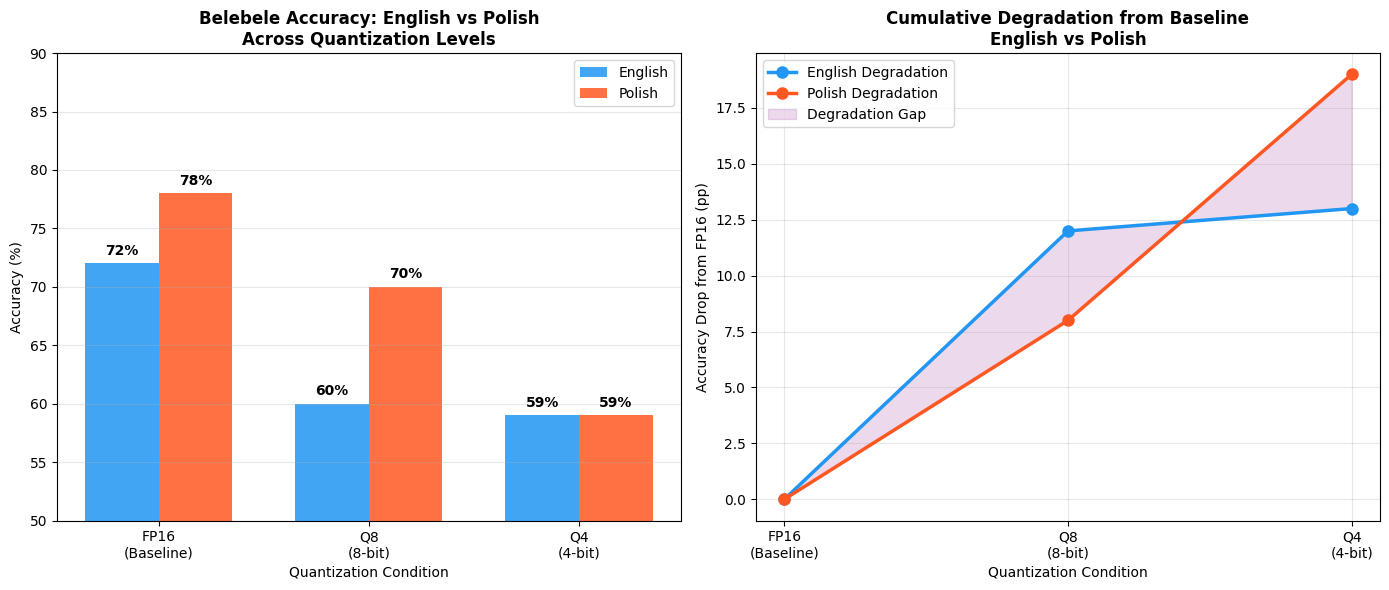

Chart saved as quantization_results.png


In [11]:
conditions = ['FP16\n(Baseline)', 'Q8\n(8-bit)', 'Q4\n(4-bit)']
en_scores = [fp16_en*100, q8_en*100, q4_en*100]
pl_scores = [fp16_pl*100, q8_pl*100, q4_pl*100]

x = np.arange(len(conditions))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

bars1 = ax1.bar(x - width/2, en_scores, width, label='English', color='#2196F3', alpha=0.85)
bars2 = ax1.bar(x + width/2, pl_scores, width, label='Polish', color='#FF5722', alpha=0.85)
ax1.set_xlabel('Quantization Condition')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Belebele Accuracy: English vs Polish\nAcross Quantization Levels', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(conditions)
ax1.set_ylim(50, 90)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{bar.get_height():.0f}%', ha='center', va='bottom', fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{bar.get_height():.0f}%', ha='center', va='bottom', fontweight='bold')

en_drops = [0, fp16_en*100-q8_en*100, fp16_en*100-q4_en*100]
pl_drops = [0, fp16_pl*100-q8_pl*100, fp16_pl*100-q4_pl*100]

ax2.plot(conditions, en_drops, 'o-', color='#2196F3', linewidth=2.5, markersize=8, label='English Degradation')
ax2.plot(conditions, pl_drops, 'o-', color='#FF5722', linewidth=2.5, markersize=8, label='Polish Degradation')
ax2.fill_between(conditions, en_drops, pl_drops, alpha=0.15, color='purple', label='Degradation Gap')
ax2.set_xlabel('Quantization Condition')
ax2.set_ylabel('Accuracy Drop from FP16 (pp)')
ax2.set_title('Cumulative Degradation from Baseline\nEnglish vs Polish', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('quantization_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as quantization_results.png")